Algoritmos Metaheuristicos  
Tarea 5 - Organizacion de Horarios (UCTP)  
Autor: Ing. Daniel Eduardo González Alvarado  
Profesor: Dr. Marco Aceves

# Importar Librerias

In [51]:
import numpy as np
import pandas as pd
from openpyxl.styles import PatternFill
import matplotlib.pyplot as plt
from collections import defaultdict

## Base de Datos

- MCIA
- LNANO
- LBIOMED
- LFIS

- Se toma de inicio un salon por semestre
- 21 salones mas labs
- Preferencia a Salones mas chicos para maestria
- 1 grupo por semestre
- Expandir horarios
- Bloques de media hora para individuos
- No puede haber dos materias del mismo semestre a la misma hora

# Cargar DB

In [2]:
materias   = pd.read_csv("./Datos/Tablas/materias.csv")
cursos     = pd.read_csv("./Datos/Tablas/cursos.csv")        # programas / carreras
grupos     = pd.read_csv("./Datos/Tablas/grupos.csv")
asig       = pd.read_csv("./Datos/Tablas/asignacion_cursos.csv")
salones    = pd.read_csv("./Datos/Tablas/salones.csv")
horarios   = pd.read_csv("./Datos/Tablas/horarios.csv")

### Unir DB

In [10]:
uctp_events = (
    asig
    .merge(grupos, on="group_id", how="left", suffixes=("", "_group"))
    .merge(materias, on="materia_id", how="left", suffixes=("", "_mat"))
    .merge(cursos, on="program_id", how="left", suffixes=("", "_program"))
)

### Reordenar

In [11]:
uctp_events = uctp_events.rename(columns={
    "name":    "group_name",     # nombre del grupo (MCIA_1, NANO_2, etc.)
    "nombre":  "program_name",   # nombre del programa (MC. Inteligencia Artificial, etc.)
    "name_mat": "subject_name"   # nombre de la materia (si tuvieras esa columna con ese nombre)
})

In [12]:
display(uctp_events.head(10))

,assignment_id,materia_id,group_id,program_id,group_name,size,semester,code,subject_name,hours_per_week,room_type_required,program_name
0,1,1,1,1,MCIA_1,10,1,MI,Metodologia_de_la_Investigacion,3,normal,MC. Inteligencia Artificial
1,2,2,1,1,MCIA_1,10,1,MA,Matematicas_Avanzadas,3,normal,MC. Inteligencia Artificial
2,3,3,1,1,MCIA_1,10,1,CA,Computacion_Avanzada,3,normal,MC. Inteligencia Artificial
3,4,4,1,1,MCIA_1,10,1,NN,Redes_Neuronales,3,normal,MC. Inteligencia Artificial
4,5,5,1,1,MCIA_1,10,1,ML,Aprendizaje_Automatico,3,normal,MC. Inteligencia Artificial
5,6,6,2,1,MCIA_2,8,2,ME,Metodos_Estadisticos,3,normal,MC. Inteligencia Artificial
6,7,7,2,1,MCIA_2,8,2,AM,Algoritmos_Metaheuristicos,3,normal,MC. Inteligencia Artificial
7,8,8,2,1,MCIA_2,8,2,DL,Aprendizaje_Profundo,3,normal,MC. Inteligencia Artificial
8,9,9,2,1,MCIA_2,8,2,OP1,Optativa_1,3,normal,MC. Inteligencia Artificial
9,10,10,2,1,MCIA_2,8,2,OP2,Optativa_2,3,normal,MC. Inteligencia Artificial


In [13]:
print("\n=== Columnas de uctp_events ===")
print(uctp_events.columns.tolist())


=== Columnas de uctp_events ===
['assignment_id', 'materia_id', 'group_id', 'program_id', 'group_name', 'size', 'semester', 'code', 'subject_name', 'hours_per_week', 'room_type_required', 'program_name']


In [14]:
uctp_events.to_csv("./Datos/Tablas/uctp_events.csv", index=False)
print("\nSe guardó 'uctp_events.csv' con la tabla base de eventos UCTP.")


Se guardó 'uctp_events.csv' con la tabla base de eventos UCTP.


# Cromosomas

In [32]:
events = pd.read_csv("./Datos/Tablas/uctp_events.csv")
salones  = pd.read_csv("./Datos/Tablas/salones.csv")
horarios = pd.read_csv("./Datos/Tablas/horarios.csv")

In [33]:
# Asegurar un índice limpio para los eventos
events = events.reset_index(drop=True)

# Bloques de 1hr (2 * 30 min)
events["duration_slots"] = events["hours_per_week"] * 2

# Mapear room_id -> índice
rooms_df = salones.reset_index(drop=True).copy()
rooms_df["room_index"] = rooms_df.index

day_map = {d: i for i, d in enumerate(horarios["day"].unique())}
horarios["day_index"] = horarios["day"].map(day_map)

In [34]:
n_events = len(events)
n_rooms  = len(rooms_df)
n_slots  = len(horarios)

In [35]:
# Buscar Salones disponibles validos
compatible_rooms = []

for _, ev in events.iterrows():
    mask = (
        (rooms_df["type"] == ev["room_type_required"]) &
        (rooms_df["capacity"] >= ev["size"])
    )
    valid_rooms = rooms_df.loc[mask, "room_index"].to_numpy()
    if len(valid_rooms) == 0:
        print("⚠️ WARNING: evento sin salón compatible -> assignment_id:",
              ev["assignment_id"])
    compatible_rooms.append(valid_rooms)


In [36]:
def random_individual():
    """Genera un individuo aleatorio (room_index, start_slot) por evento."""
    chrom = np.zeros((n_events, 2), dtype=int)
    for i, ev in events.iterrows():
        # Room
        if len(compatible_rooms[i]) > 0:
            room_idx = np.random.choice(compatible_rooms[i])
        else:
            room_idx = np.random.randint(0, n_rooms)

        # Slot
        dur = int(ev["duration_slots"])
        max_start = max(0, n_slots - dur)
        start_slot = np.random.randint(0, max_start + 1)

        chrom[i, 0] = room_idx
        chrom[i, 1] = start_slot
    return chrom


In [57]:
def evaluate_fitness(chrom):
    penalty = 0.0

    W_ROOM_CONFLICT   = 15000
    W_GROUP_CONFLICT  = 10000
    W_CAPACITY        = 500
    W_ROOM_TYPE       = 500
    W_CROSS_DAY       = 300

    W_MAX_CONSEC      = 500  # ajusta este valor a tu gusto

    room_occupancy  = {}
    group_occupancy = {}

    group_day_slots = defaultdict(list)

    for i, ev in events.iterrows():
        room_idx   = chrom[i, 0]
        start_slot = chrom[i, 1]
        dur        = int(ev["duration_slots"])

        # Capacity & type
        room_row = rooms_df.iloc[room_idx]
        if ev["size"] > room_row["capacity"]:
            penalty += W_CAPACITY
        if room_row["type"] != ev["room_type_required"]:
            penalty += W_ROOM_TYPE

        end_slot = start_slot + dur
        if end_slot > n_slots:
            penalty += W_CROSS_DAY
            end_slot = n_slots

        slots = np.arange(start_slot, end_slot)
        day_indices = horarios.loc[slots, "day_index"].to_numpy()

        # Cruce de día dentro del mismo evento
        if np.any(day_indices != day_indices[0]):
            penalty += W_CROSS_DAY

        group_id = ev["group_id"]

        # NUEVO: registrar slots por grupo y día
        for s, d in zip(slots, day_indices):
            group_day_slots[(group_id, int(d))].append(int(s))

        for s in slots:
            # Conflictos en salón
            key_r = (room_idx, s)
            if key_r in room_occupancy:
                penalty += W_ROOM_CONFLICT
            else:
                room_occupancy[key_r] = i

            # Conflictos de grupo
            key_g = (group_id, s)
            if key_g in group_occupancy:
                penalty += W_GROUP_CONFLICT
            else:
                group_occupancy[key_g] = i

    # Penalizar 3 o más horas seguidas
    for (group_id, day_idx), slot_list in group_day_slots.items():
        if not slot_list:
            continue

        # Ordenar y quitar duplicados
        sorted_slots = sorted(set(slot_list))

        # Buscar rachas consecutivas
        streak = 1
        for k in range(1, len(sorted_slots)):
            if sorted_slots[k] == sorted_slots[k-1] + 1:
                streak += 1
                if streak >= 2:
                    penalty += W_MAX_CONSEC
            else:
                streak = 1

    return penalty


# Iniciar Poblacion

In [58]:
def init_population(pop_size):
    return [random_individual() for _ in range(pop_size)]


# Seleccion por Torneo

In [39]:
def tournament_selection(population, fitnesses, k=3):
    """
    Selección por torneo: elige k individuos al azar y devuelve el mejor.
    """
    idxs = np.random.choice(len(population), size=k, replace=False)
    best_idx = idxs[0]
    best_fit = fitnesses[best_idx]
    for i in idxs[1:]:
        if fitnesses[i] < best_fit:   # menor = mejor
            best_fit = fitnesses[i]
            best_idx = i
    return population[best_idx].copy()


# Cruce (Crossover)

In [40]:
def crossover(parent1, parent2, pc=0.9):
    """
    Cruce de un punto. Devuelve dos hijos.
    pc = probabilidad de aplicar cruce.
    """
    if np.random.rand() > pc:
        # Sin cruce: copiamos padres
        return parent1.copy(), parent2.copy()

    n = parent1.shape[0]
    cut = np.random.randint(1, n)  # entre 1 y n-1
    child1 = np.vstack([parent1[:cut], parent2[cut:]])
    child2 = np.vstack([parent2[:cut], parent1[cut:]])
    return child1, child2


# Mutacion

In [41]:
def mutate(ind, pm_room=0.05, pm_time=0.05):
    """
    Mutación sencilla sobre un individuo.
    pm_room: prob. de mutar salón de un evento.
    pm_time: prob. de mutar slot de inicio de un evento.
    """
    for i, ev in events.iterrows():
        # Mutar salón
        if np.random.rand() < pm_room:
            if len(compatible_rooms[i]) > 0:
                ind[i, 0] = np.random.choice(compatible_rooms[i])
            else:
                ind[i, 0] = np.random.randint(0, n_rooms)

        # Mutar tiempo
        if np.random.rand() < pm_time:
            dur = int(ev["duration_slots"])
            max_start = max(0, n_slots - dur)
            ind[i, 1] = np.random.randint(0, max_start + 1)

    return ind


# Ejecucion

In [42]:
def run_ga(
    pop_size=500,
    generations=500,
    tournament_k=3,
    pc=0.9,
    pm_room=0.05,
    pm_time=0.05,
    verbose=True,
    plot=True,          # Metricas
    return_stats=False  
):
    # 1) Población inicial
    population = init_population(pop_size)
    fitnesses = np.array([evaluate_fitness(ind) for ind in population])

    best_idx = np.argmin(fitnesses)
    best_ind = population[best_idx].copy()
    best_fit = fitnesses[best_idx]

    history = []  # [(gen, best_fit)]

    # Metricas por generación
    gens = []
    best_per_gen = []
    mean_per_gen = []

    for gen in range(1, generations + 1):
        new_population = []

        # Elitismo
        new_population.append(best_ind.copy())

        while len(new_population) < pop_size:
            # Selección
            p1 = tournament_selection(population, fitnesses, k=tournament_k)
            p2 = tournament_selection(population, fitnesses, k=tournament_k)

            # Cruce
            c1, c2 = crossover(p1, p2, pc=pc)

            # Mutación
            c1 = mutate(c1, pm_room=pm_room, pm_time=pm_time)
            c2 = mutate(c2, pm_room=pm_room, pm_time=pm_time)

            new_population.append(c1)
            if len(new_population) < pop_size:
                new_population.append(c2)

        population = new_population
        fitnesses = np.array([evaluate_fitness(ind) for ind in population])

        # Actualizar mejor global
        gen_best_idx = np.argmin(fitnesses)
        gen_best_fit = fitnesses[gen_best_idx]
        if gen_best_fit < best_fit:
            best_fit = gen_best_fit
            best_ind = population[gen_best_idx].copy()

        # Estadísticas de generación
        gen_mean_fit = float(np.mean(fitnesses))

        gens.append(gen)
        best_per_gen.append(best_fit)      # mejor global
        mean_per_gen.append(gen_mean_fit)  # promedio de la generación

        history.append((gen, best_fit))

        if verbose and gen % 10 == 0:
            print(f"[Gen {gen:4d}] Mejor fitness: {best_fit:.3f} | "
                  f"Media generación: {gen_mean_fit:.3f}")

    # Gráfica de Metricas
    if plot:
        plt.figure()
        plt.plot(gens, best_per_gen, label="Mejor fitness (global)")
        plt.plot(gens, mean_per_gen, label="Fitness promedio por generación")
        plt.xlabel("Generación")
        plt.ylabel("Fitness")
        plt.title("Evolución del fitness")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    if return_stats:
        stats = {
            "gens": np.array(gens),
            "best": np.array(best_per_gen),
            "mean": np.array(mean_per_gen),
        }
        return best_ind, best_fit, history, stats
    else:
        return best_ind, best_fit, history


[Gen   10] Mejor fitness: 4255800.000 | Media generación: 5479859.500
[Gen   20] Mejor fitness: 4255800.000 | Media generación: 5326280.000
[Gen   30] Mejor fitness: 4010200.000 | Media generación: 5254793.000
[Gen   40] Mejor fitness: 3955200.000 | Media generación: 5192765.500
[Gen   50] Mejor fitness: 3883900.000 | Media generación: 5123518.500
[Gen   60] Mejor fitness: 3862500.000 | Media generación: 5069270.500
[Gen   70] Mejor fitness: 3862500.000 | Media generación: 4973541.000
[Gen   80] Mejor fitness: 3862500.000 | Media generación: 4883950.000
[Gen   90] Mejor fitness: 3768000.000 | Media generación: 5024122.000
[Gen  100] Mejor fitness: 3660100.000 | Media generación: 5067117.500
[Gen  110] Mejor fitness: 3660100.000 | Media generación: 5035183.000
[Gen  120] Mejor fitness: 3660100.000 | Media generación: 5004099.500
[Gen  130] Mejor fitness: 3628700.000 | Media generación: 4855598.000
[Gen  140] Mejor fitness: 3628700.000 | Media generación: 5006044.000
[Gen  150] Mejor fit

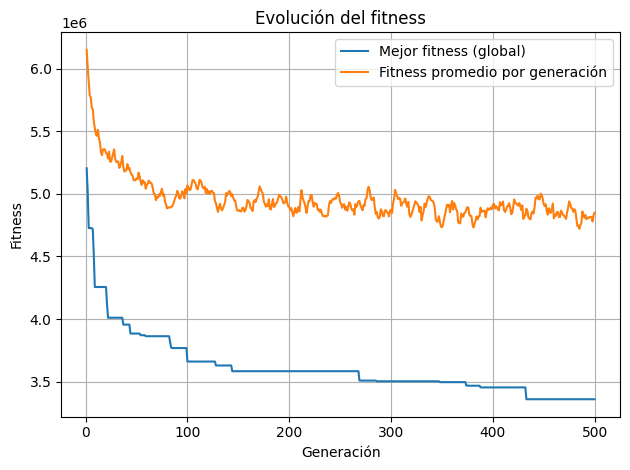

Mejor fitness final: 3358900.0


In [62]:
best_ind, best_fit, history = run_ga(
    pop_size=200,
    generations=500,
    tournament_k=3,
    pc=0.9,
    pm_room=0.05,
    pm_time=0.05,
    verbose=True
)


print("Mejor fitness final:", best_fit)


# Decodificar
Para mostrar un Horario mas sencillo de leer

In [63]:
def build_day_timetable(chrom, day_label):
    """
    Construye un DataFrame horario para un día:
    - Filas: bloques de tiempo (start-end)
    - Columnas: salones
    - Celdas: "Materia (Grupo)"
    """
    # Slots de ese día
    day_slots = horarios[horarios["day"] == day_label].copy()
    if day_slots.empty:
        return pd.DataFrame()  # por si no hay clases ese día

    # Index de la tabla: "HH:MM-HH:MM"
    time_labels = day_slots["start"] + "-" + day_slots["end"]
    index = time_labels.to_list()

    # Columnas = nombres de salones (orden alfabético)
    room_names = sorted(rooms_df["name"].unique().tolist())

    # DataFrame vacío
    table = pd.DataFrame("", index=index, columns=room_names)

    # ⚠️ Usar el índice global de 'horarios' como clave
    # reset_index() crea una col 'index' con el índice original
    day_slots_reset = day_slots.reset_index()  # 'index' = índice global de horarios
    slot_to_row = {
        int(row["index"]): idx          # s (del cromosoma) es este 'index'
        for idx, row in day_slots_reset.iterrows()
    }

    # Aseguramos índice posicional en events
    events_reset = events.reset_index(drop=True)

    # Rellenar la tabla con las asignaciones
    for idx, ev in events_reset.iterrows():
        room_idx   = chrom[idx, 0]      # idx posicional
        start_slot = chrom[idx, 1]
        dur        = int(ev["duration_slots"])
        end_slot   = start_slot + dur

        room_row   = rooms_df.iloc[room_idx]
        room_name  = room_row["name"]

        # Nombre de la clase a mostrar en la celda
        subj = ev.get("subject_name", ev.get("code", "MATERIA"))
        grp  = ev["group_name"]
        label = f"{subj} ({grp})"

        # Slots que ocupa esta clase (índices de 'horarios')
        slots = np.arange(start_slot, min(end_slot, len(horarios)))

        for s in slots:
            # Sólo usamos los slots que correspondan a este día
            if s in slot_to_row:
                row_idx = slot_to_row[s]
                time_str = index[row_idx]

                current = table.at[time_str, room_name]
                if current == "":
                    table.at[time_str, room_name] = label
                else:
                    table.at[time_str, room_name] = current + " | " + label

    return table


In [64]:
def export_schedule_by_day(
        chrom,
        excel_filename="horario_por_dias.xlsx",
        export_csv=False):

    # Colores por curso
    COLOR_MAP = {
        "MCIA": "ADD8E6",   # azul claro
        "Nano": "FFFF99",   # amarillo
        "BioMed": "98FB98", # verde claro
        "Fis": "D8BFD8",    # morado claro
        "cruce": "FF7F7F"   # rojo
    }

    unique_days = list(horarios["day"].unique())

    with pd.ExcelWriter(excel_filename, engine="openpyxl") as writer:
        for day_label in unique_days:

            df_day = build_day_timetable(chrom, day_label)
            if df_day.empty:
                continue

            sheet_name = str(day_label)[:31]
            df_day.to_excel(writer, sheet_name=sheet_name)

            ws = writer.sheets[sheet_name]

            # Encontrar cada celda del dataframe
            for row_idx, row in enumerate(df_day.itertuples(), start=2):
                for col_idx, cell_value in enumerate(row[1:], start=2):

                    if pd.isna(cell_value):
                        continue

                    # Detectar cruces → celda en rojo
                    if isinstance(cell_value, list) or "|" in str(cell_value):
                        fill = PatternFill(start_color=COLOR_MAP["cruce"],
                                           end_color=COLOR_MAP["cruce"],
                                           fill_type="solid")
                    else:
                        # Identificar curso
                        curso = None
                        val = str(cell_value)

                        if "MCIA" in val:
                            curso = "MCIA"
                        elif "NANO" in val or "Nano" in val:
                            curso = "Nano"
                        elif "BIOMED" in val or "BioMed" in val:
                            curso = "BioMed"
                        elif "FIS" in val or "Fis" in val or "FISICO" in val:
                            curso = "Fis"

                        if curso is not None:
                            color = COLOR_MAP[curso]
                            fill = PatternFill(start_color=color, end_color=color, fill_type="solid")
                        else:
                            fill = None

                    if fill:
                        ws.cell(row=row_idx, column=col_idx).fill = fill

            if export_csv:
                df_day.to_csv(f"horario_{day_label}.csv")


    print(f"Archivo Excel generado: {excel_filename}")


In [65]:
export_schedule_by_day(best_ind,
                       excel_filename="horario_por_dias.xlsx",
                       export_csv=True)  # pon False si no quieres los CSV


Archivo Excel generado: horario_por_dias.xlsx
